# Feature Engineering: Engagement Features
By Rizqi


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def safe_divide(a, b):
    return a / b.replace(0, np.nan)


## Load Data


In [2]:
df = pd.read_csv('../../data/Data_Cleaned_Wildan.csv')
print(df.columns)

Index(['video_title', 'duration', 'average_percentage_viewed_pct',
       'engaged_views', 'youtube_premium_idr', 'watch_page_ads_idr',
       'estimated_adsense_revenue_idr', 'youtube_ad_revenue_idr',
       'ad_impressions', 'playback_based_cpm_idr', 'cpm_idr',
       'estimated_monetized_playbacks', 'rpm_idr', 'views', 'watch_time_hours',
       'subscribers', 'estimated_revenue_idr', 'impressions',
       'impressions_click_through_rate_pct', 'video_id', 'ts1_views',
       'ts2_views', 'ts3_views', 'ts4_views', 'publish_time_wib',
       'avg_view_duration_sec', 'publish_date', 'publish_hour', 'is_viral',
       'views_log', 'watch_time_hours_log', 'engaged_views_log',
       'impressions_log', 'estimated_revenue_idr_log', 'ad_impressions_log'],
      dtype='str')


## 1. engaged_view_rate
engaged_views / views


In [3]:
print(df.columns)

Index(['video_title', 'duration', 'average_percentage_viewed_pct',
       'engaged_views', 'youtube_premium_idr', 'watch_page_ads_idr',
       'estimated_adsense_revenue_idr', 'youtube_ad_revenue_idr',
       'ad_impressions', 'playback_based_cpm_idr', 'cpm_idr',
       'estimated_monetized_playbacks', 'rpm_idr', 'views', 'watch_time_hours',
       'subscribers', 'estimated_revenue_idr', 'impressions',
       'impressions_click_through_rate_pct', 'video_id', 'ts1_views',
       'ts2_views', 'ts3_views', 'ts4_views', 'publish_time_wib',
       'avg_view_duration_sec', 'publish_date', 'publish_hour', 'is_viral',
       'views_log', 'watch_time_hours_log', 'engaged_views_log',
       'impressions_log', 'estimated_revenue_idr_log', 'ad_impressions_log'],
      dtype='str')


In [4]:
df.head()

,video_title,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,...,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,watch_time_hours_log,engaged_views_log,impressions_log,estimated_revenue_idr_log,ad_impressions_log
0,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,51.37,7225.0,616.644,41535.555,0.000,0.000,0.0,0.000,...,308,2026-05-08,19,0,8.885441,6.429131,8.885441,10.174278,0.000000,0.000000
1,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,46.85,9831.0,196.718,9588.286,9588.286,17445.450,2160.0,9872.920,...,281,2026-05-08,11,0,9.193398,6.644651,9.193398,10.395406,9.188708,7.678326
2,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,40.15,4177.0,285.101,19902.939,19902.939,36210.022,3854.0,11169.038,...,240,2026-05-07,7,0,8.337588,5.636598,8.337588,9.694678,9.912895,8.257126
3,HINA INDONESIA MISKIN! RINGGIT BENAR-BENAR TAK...,600.0,46.33,4948.0,306.240,24929.460,24929.460,45349.960,4146.0,13291.313,...,278,2026-05-06,7,0,8.506941,5.948297,8.506941,9.932949,10.136055,8.330140
4,PETRONAS BANGKRUT?! DPR DAN RAJA MALAYSIA NGAM...,600.0,46.44,7111.0,516.474,37923.744,37923.744,68990.660,7031.0,11767.126,...,278,2026-05-06,15,0,8.869539,6.312382,8.869539,10.248707,10.556886,8.858226


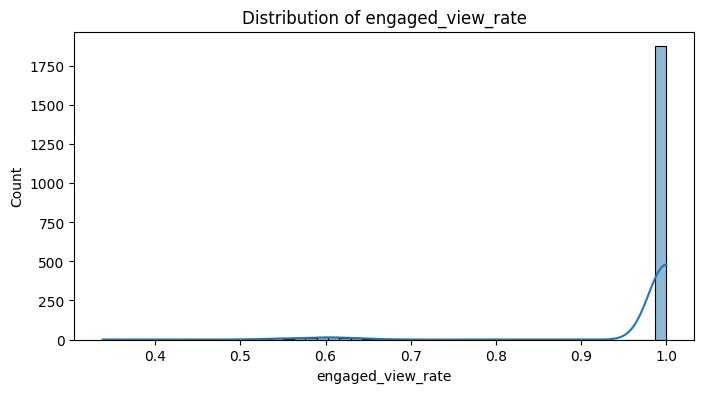

Outliers in engaged_view_rate: 112


In [5]:
df['engaged_view_rate'] = safe_divide(df['engaged_views'], df['views']).fillna(0)

plt.figure(figsize=(8,4))
sns.histplot(df['engaged_view_rate'], bins=50, kde=True)
plt.title('Distribution of engaged_view_rate')
plt.show()

# IQR Outlier check
Q1 = df['engaged_view_rate'].quantile(0.25)
Q3 = df['engaged_view_rate'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['engaged_view_rate'] < (Q1 - 1.5 * IQR)) | (df['engaged_view_rate'] > (Q3 + 1.5 * IQR))]
print(f'Outliers in engaged_view_rate: {len(outliers)}')


## 2. ctr_normalized
impressions_click_through_rate_pct / 100


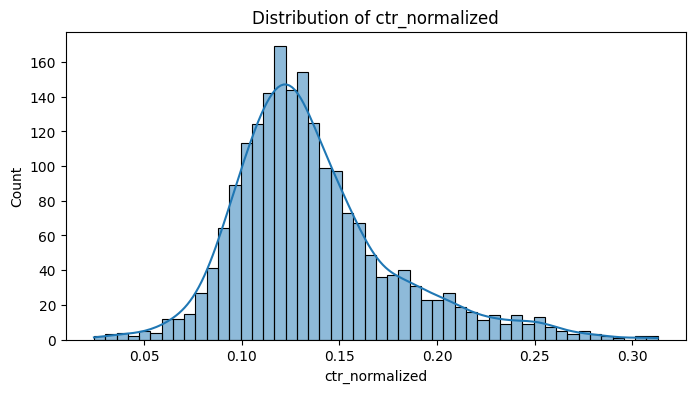

Outliers in ctr_normalized: 109


In [6]:
df['ctr_normalized'] = (df['impressions_click_through_rate_pct'] / 100).fillna(0).clip(0, 1)

plt.figure(figsize=(8,4))
sns.histplot(df['ctr_normalized'], bins=50, kde=True)
plt.title('Distribution of ctr_normalized')
plt.show()

# IQR Outlier check
Q1 = df['ctr_normalized'].quantile(0.25)
Q3 = df['ctr_normalized'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['ctr_normalized'] < (Q1 - 1.5 * IQR)) | (df['ctr_normalized'] > (Q3 + 1.5 * IQR))]
print(f'Outliers in ctr_normalized: {len(outliers)}')


## 3. retention_proxy
average_percentage_viewed_pct / 100


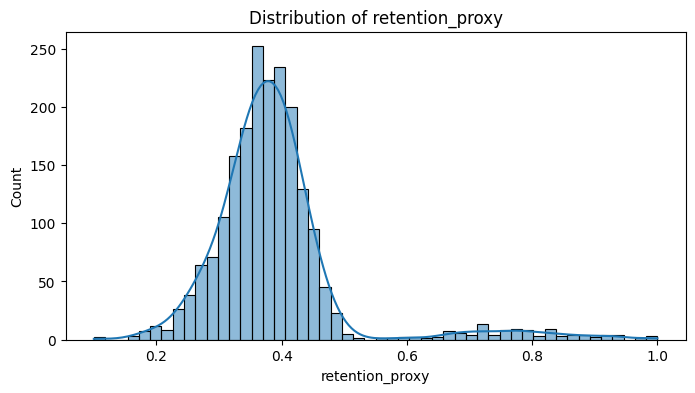

Outliers in retention_proxy: 131


In [7]:
df['retention_proxy'] = (df['average_percentage_viewed_pct'] / 100).fillna(0).clip(0, 1)

plt.figure(figsize=(8,4))
sns.histplot(df['retention_proxy'], bins=50, kde=True)
plt.title('Distribution of retention_proxy')
plt.show()

# IQR Outlier check
Q1 = df['retention_proxy'].quantile(0.25)
Q3 = df['retention_proxy'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['retention_proxy'] < (Q1 - 1.5 * IQR)) | (df['retention_proxy'] > (Q3 + 1.5 * IQR))]
print(f'Outliers in retention_proxy: {len(outliers)}')


## 4. engagement_score
(engaged_view_rate * 0.4) + (ctr_normalized * 0.4) + (retention_proxy * 0.2)


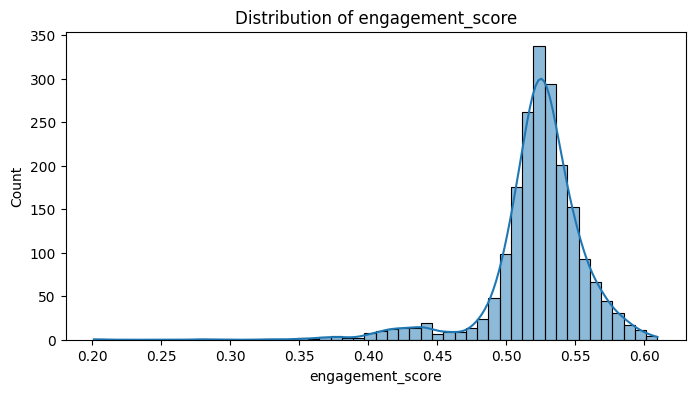

Outliers in engagement_score: 165


In [8]:
df['engagement_score'] = (df['engaged_view_rate'] * 0.4) + (df['ctr_normalized'] * 0.4) + (df['retention_proxy'] * 0.2)

plt.figure(figsize=(8,4))
sns.histplot(df['engagement_score'], bins=50, kde=True)
plt.title('Distribution of engagement_score')
plt.show()

# IQR Outlier check
Q1 = df['engagement_score'].quantile(0.25)
Q3 = df['engagement_score'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['engagement_score'] < (Q1 - 1.5 * IQR)) | (df['engagement_score'] > (Q3 + 1.5 * IQR))]
print(f'Outliers in engagement_score: {len(outliers)}')


## Save Features


In [9]:
cols_to_save = ['video_id', 'engaged_view_rate', 'ctr_normalized', 'retention_proxy', 'engagement_score']
if 'video_id' in df.columns:
    df[cols_to_save].to_csv('../../data/processed/features_engagement.csv', index=False)
    print('Saved to features_engagement.csv')
else:
    print('video_id not found in dataset')


Saved to features_engagement.csv
